In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_smartphone_dataset.csv") 

In [3]:
df.shape

(919, 14)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.head()

,brand,model,price,avg_rating,reviews,color,RAM,ROM,battery,Rear Camera,Front Camera,display_inches,display_type,processor
0,Motorola,Motorola g05,6999,4.2,49084,Forest green,4,64,5100,50MP,8MP,6.67,HD+ Display,Helio G81 Processor
1,Poco,Poco c71,6999,4.1,11677,Desert gold,6,128,5200,32MP,8MP,6.88,HD+ Display,Unisoc T7250\nMax clock speed: \n2 x A75@1.8GH...
2,Poco,Poco c71,6399,3.9,25608,Cool blue,4,64,5200,32MP,8MP,6.88,HD+ Display,Unisoc T7250\nMax clock speed: \n2 x A75@1.8GH...
3,Samsung,Samsung galaxy f05,6499,4.2,64333,Twilight blue,4,64,5000,50MP + 2MP,8MP,6.74,HD+ Display,Helio G85 Processor
4,Poco,Poco c71,6999,4.1,11677,Power black,6,128,5200,32MP,8MP,6.88,HD+ Display,Unisoc T7250\nMax clock speed: \n2 x A75@1.8GH...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           919 non-null    object 
 1   model           919 non-null    object 
 2   price           919 non-null    int64  
 3   avg_rating      919 non-null    float64
 4   reviews         919 non-null    int64  
 5   color           919 non-null    object 
 6   RAM             919 non-null    int64  
 7   ROM             919 non-null    int64  
 8   battery         919 non-null    int64  
 9   Rear Camera     919 non-null    object 
 10  Front Camera    763 non-null    object 
 11  display_inches  919 non-null    float64
 12  display_type    919 non-null    object 
 13  processor       770 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 100.6+ KB


In [7]:
df.isnull().sum()

brand               0
model               0
price               0
avg_rating          0
reviews             0
color               0
RAM                 0
ROM                 0
battery             0
Rear Camera         0
Front Camera      156
display_inches      0
display_type        0
processor         149
dtype: int64

In [8]:
df.describe()

,price,avg_rating,reviews,RAM,ROM,battery,display_inches
count,919.000000,919.000000,919.000000,919.000000,919.000000,919.000000,919.000000
mean,25228.879217,4.322524,23155.063112,7.487486,182.363439,5327.482046,6.661021
std,23505.801537,0.205172,49538.108756,2.829121,106.623371,760.825416,0.250670
min,4499.000000,2.000000,4.000000,1.000000,8.000000,2000.000000,3.000000
25%,11499.000000,4.200000,1107.000000,6.000000,128.000000,5000.000000,6.670000
50%,17499.000000,4.300000,4130.000000,8.000000,128.000000,5100.000000,6.700000
75%,27999.000000,4.400000,18966.000000,8.000000,256.000000,6000.000000,6.770000
max,157900.000000,4.700000,364334.000000,16.000000,512.000000,7550.000000,7.600000


In [9]:
df['Front Camera']=df['Front Camera'].fillna('Unknow')

In [10]:
df['processor']=df['processor'].fillna('Unknow')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           919 non-null    object 
 1   model           919 non-null    object 
 2   price           919 non-null    int64  
 3   avg_rating      919 non-null    float64
 4   reviews         919 non-null    int64  
 5   color           919 non-null    object 
 6   RAM             919 non-null    int64  
 7   ROM             919 non-null    int64  
 8   battery         919 non-null    int64  
 9   Rear Camera     919 non-null    object 
 10  Front Camera    919 non-null    object 
 11  display_inches  919 non-null    float64
 12  display_type    919 non-null    object 
 13  processor       919 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 100.6+ KB


In [12]:
cat_columns=['brand','model','color','RAM','ROM','Rear Camera','display_type','processor']
num_columns=['price','avg_rating','reviews','battery','display_inches']

In [13]:
def valueC(df, column):
    print(column)
    print(df[column].value_counts())
    
    top5 = df[column].value_counts().head(5).index

    # 2. Filter dataframe to only these top 5
    df_top5 = df[df[column].isin(top5)]

    # 3. Plot
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_top5, x=column, order=top5)
    plt.title(f"Top 5 {column} Countplot")
    plt.xticks(rotation=45)
    plt.show()

In [14]:
# for cc in cat_columns:
#     valueC(df,cc)

In [15]:
def numericalUnivariant(df,col):
    plt.figure(figsize=(12, 8))
    plt.suptitle(col, fontsize=18, fontweight="bold")
    # ---------------- Subplot 1: Histogram ----------------
    plt.subplot(2, 2, 1)
    sns.histplot(data=df, x=col, kde=False)
    plt.title("Histogram")

    # ---------------- Subplot 2: KDE Plot ----------------
    plt.subplot(2, 2, 2)
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title("KDE Plot")

    # ---------------- Subplot 3: Boxplot ----------------
    plt.subplot(2, 1, 2)
    sns.boxplot(data=df, x=col)
    plt.title("Boxplot")
    
    plt.tight_layout()
    plt.show()

In [16]:
# for col in num_columns:
#     numericalUnivariant(df,col)

In [17]:
def numerical_vs_numerical(df, col1, col2):
    plt.figure(figsize=(14, 10))
    plt.suptitle(f"{col1} vs {col2} (Numerical vs Numerical)", fontsize=18, fontweight="bold")

    # Scatter Plot
    plt.subplot(2, 2, 1)
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title("Scatter Plot")

    # Correlation Value
    plt.subplot(2, 2, 2)
    corr = df[[col1, col2]].corr().iloc[0, 1]
    sns.heatmap(df[[col1, col2]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Correlation = {corr:.2f}")

    # Line Plot
    plt.subplot(2, 1, 2)
    sns.lineplot(data=df, x=col1, y=col2)
    plt.title("Line Plot")

    plt.tight_layout()
    plt.show()


In [18]:
def categorical_vs_numerical(df, cat_col, num_col):
    plt.figure(figsize=(14, 10))
    plt.suptitle(f"{cat_col} vs {num_col} (Categorical vs Numerical)", fontsize=18, fontweight="bold")

    # Boxplot
    plt.subplot(2, 2, 1)
    sns.boxplot(data=df, x=cat_col, y=num_col)
    plt.xticks(rotation=45)
    plt.title("Boxplot")

    # Violin plot
    plt.subplot(2, 2, 2)
    sns.violinplot(data=df, x=cat_col, y=num_col)
    plt.xticks(rotation=45)
    plt.title("Violin Plot")

    # Groupby mean bar plot
    plt.subplot(2, 1, 2)
    group_mean = df.groupby(cat_col)[num_col].mean().reset_index()
    sns.barplot(data=group_mean, x=cat_col, y=num_col)
    plt.xticks(rotation=45)
    plt.title("Groupby Mean")

    plt.tight_layout()
    plt.show()


In [19]:
def categorical_vs_categorical(df, col1, col2):
    plt.figure(figsize=(14, 10))
    plt.suptitle(f"{col1} vs {col2} (Categorical vs Categorical)", fontsize=18, fontweight="bold")

    # Cross-tab heatmap
    plt.subplot(1, 1, 1)
    ctab = pd.crosstab(df[col1], df[col2])
    sns.heatmap(ctab, annot=True, fmt="d", cmap="Blues")
    plt.title("Cross-tab Heatmap")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


In [20]:
# for i, col1 in enumerate(num_columns):
#     for j, col2 in enumerate(num_columns):
#         if j > i:
#             numerical_vs_numerical(df, col1, col2)

In [21]:
# for i, col1 in enumerate(cat_columns):
#     for j, col2 in enumerate(cat_columns):
#         if j > i:
#             categorical_vs_categorical(df, col1, col2)

In [22]:
# for i, col1 in enumerate(num_columns):
#     for j, col2 in enumerate(cat_columns):
#         if j > i:
#             categorical_vs_numerical(df, col1, col2)

In [23]:
df.sample()

,brand,model,price,avg_rating,reviews,color,RAM,ROM,battery,Rear Camera,Front Camera,display_inches,display_type,processor
565,Samsung,Samsung galaxy s25 5g,74999,4.6,2149,Mint,12,256,4000,50MP + 10MP + 12MP,12MP,6.2,Full HD+ Display,8 Elite for Galaxy Processor


In [24]:
df_grouped = df.groupby(["brand", "model"]).agg({
    "price": "mean",
    "avg_rating": "mean",
    "battery": "mean",
    "reviews": "sum",
    "color": pd.Series.nunique,      # distinct count
    "RAM": "median",
    "ROM": "median",
    "display_inches":"mean"
}).reset_index()


In [25]:
df_grouped.shape

(276, 10)

In [26]:
df_grouped.duplicated().sum()

np.int64(0)

In [27]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           276 non-null    object 
 1   model           276 non-null    object 
 2   price           276 non-null    float64
 3   avg_rating      276 non-null    float64
 4   battery         276 non-null    float64
 5   reviews         276 non-null    int64  
 6   color           276 non-null    int64  
 7   RAM             276 non-null    float64
 8   ROM             276 non-null    float64
 9   display_inches  276 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 21.7+ KB


In [28]:
cat_columns=['brand','model','RAM','ROM']
num_columns=['price','avg_rating','reviews','battery','display_inches','color']

In [29]:
# for cc in cat_columns:
#     valueC(df_grouped,cc)

In [30]:
# for col in num_columns:
#     numericalUnivariant(df_grouped,col)

In [31]:
# for i, col1 in enumerate(num_columns):
#     for j, col2 in enumerate(num_columns):
#         if j > i:
#             numerical_vs_numerical(df_grouped, col1, col2)

In [32]:
# for i, col1 in enumerate(cat_columns):
#     for j, col2 in enumerate(cat_columns):
#         if j > i:
#             categorical_vs_categorical(df_grouped, col1, col2)

In [33]:
# for i, col1 in enumerate(num_columns):
#     for j, col2 in enumerate(cat_columns):
#         if j > i:
#             categorical_vs_numerical(df_grouped, col2, col1)

In [34]:
df_grouped['user']=df_grouped['reviews']*10

Total Brands: 27


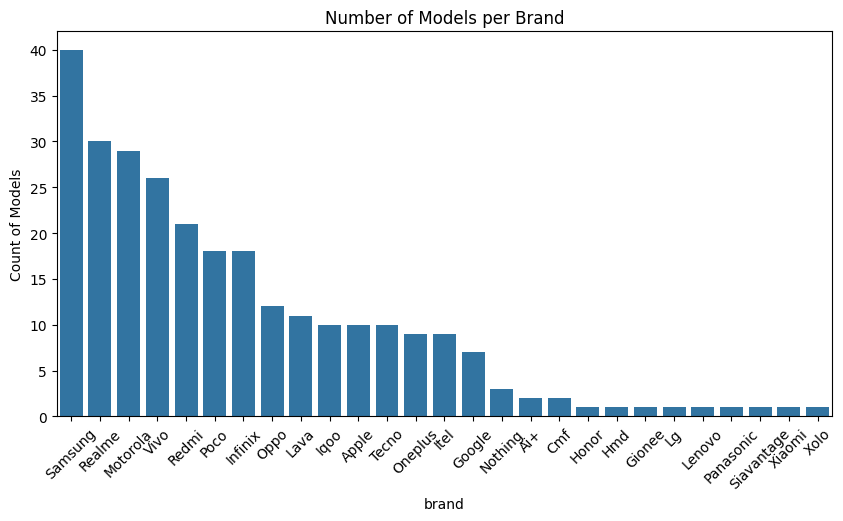

In [35]:
# 1) How many brands are on Flipkart?

print("Total Brands:", df_grouped["brand"].nunique())

plt.figure(figsize=(10,5))
sns.countplot(data=df_grouped, x="brand", 
              order=df_grouped["brand"].value_counts().index)
plt.title("Number of Models per Brand")
plt.xticks(rotation=45)
plt.ylabel("Count of Models")
plt.show()

Total Smartphone Users (Customers): 212795030


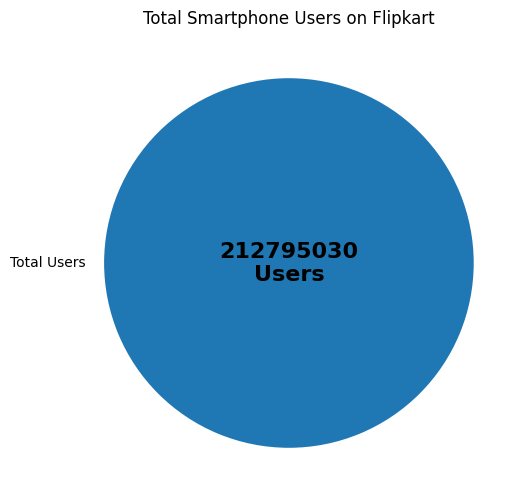

In [36]:
# 2) How many total smartphone users are on Flipkart?

total_users = df_grouped["user"].sum()
print("Total Smartphone Users (Customers):", total_users)

plt.figure(figsize=(6,6))
plt.pie([total_users], labels=["Total Users"])
plt.text(0, 0, f"{total_users}\nUsers", ha='center', va='center', fontsize=16, fontweight='bold')
plt.title("Total Smartphone Users on Flipkart")
plt.show()

Brand with the Highest Models:
 brand
Samsung    40
Name: model, dtype: int64


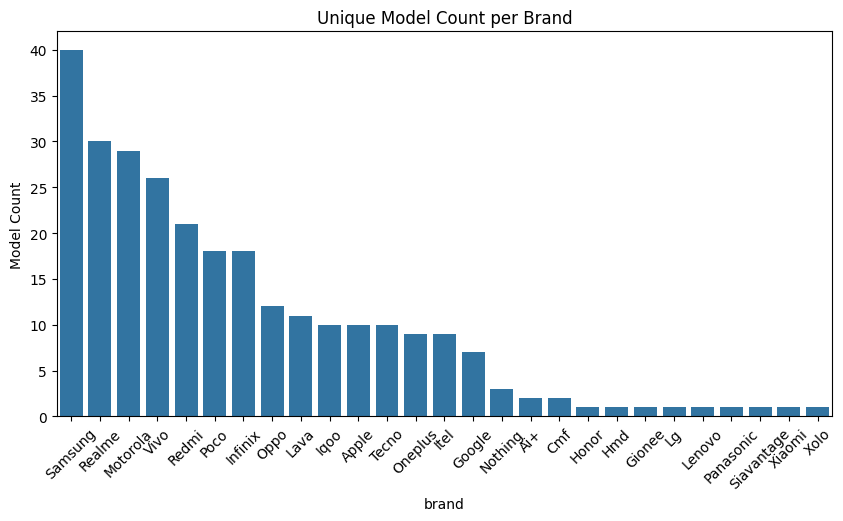

In [37]:
# 3) Which brand has the highest number of models?

brand_model_count = (
    df_grouped.groupby("brand")["model"]
    .nunique()
    .sort_values(ascending=False)
)

print("Brand with the Highest Models:\n", brand_model_count.head(1))

plt.figure(figsize=(10,5))
sns.barplot(x=brand_model_count.index, y=brand_model_count.values)
plt.title("Unique Model Count per Brand")
plt.xticks(rotation=45)
plt.ylabel("Model Count")
plt.show()

Brand with the Highest Customers:
 brand
Motorola    61268990
Name: user, dtype: int64


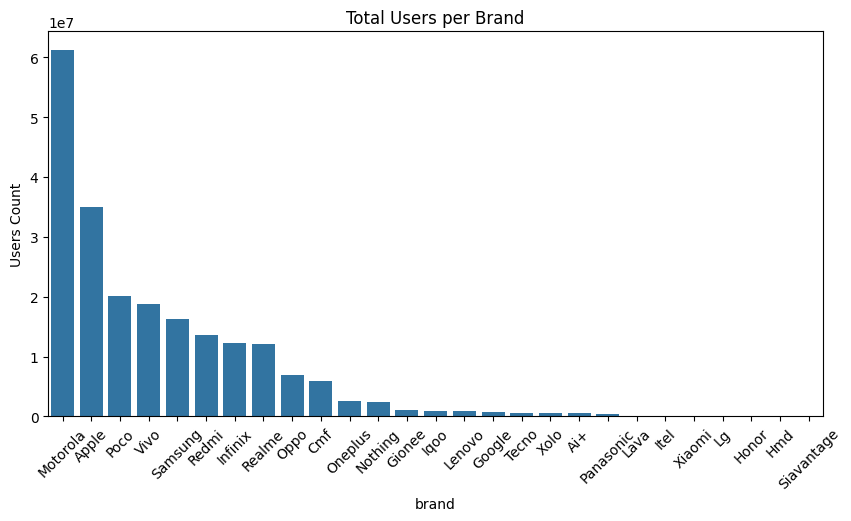

In [38]:
# 4) Which brand has the highest number of users?

brand_users = (
    df_grouped.groupby("brand")["user"]
    .sum()
    .sort_values(ascending=False)
)
print("Brand with the Highest Customers:\n", brand_users.head(1))

plt.figure(figsize=(10,5))
sns.barplot(x=brand_users.index, y=brand_users.values)
plt.title("Total Users per Brand")
plt.xticks(rotation=45)
plt.ylabel("Users Count")
plt.show()

Average Price of Each Brand:
 brand
Apple         81728.800000
Google        69249.000000
Xiaomi        39199.000000
Samsung       34153.491190
Oneplus       32805.554233
Nothing       26665.666667
Honor         26326.000000
Vivo          26102.557692
Oppo          24401.527778
Iqoo          21122.919167
Lg            19990.000000
Motorola      18508.023810
Cmf           18499.000000
Realme        17961.476587
Poco          15108.550926
Panasonic     13990.000000
Tecno         13689.100000
Redmi         13671.085089
Hmd           12499.000000
Infinix       12432.333333
Lenovo        12000.000000
Lava           8115.136364
Ai+            7674.000000
Itel           7325.111111
Gionee         5649.000000
Xolo           5149.000000
Siavantage     4499.000000
Name: price, dtype: float64


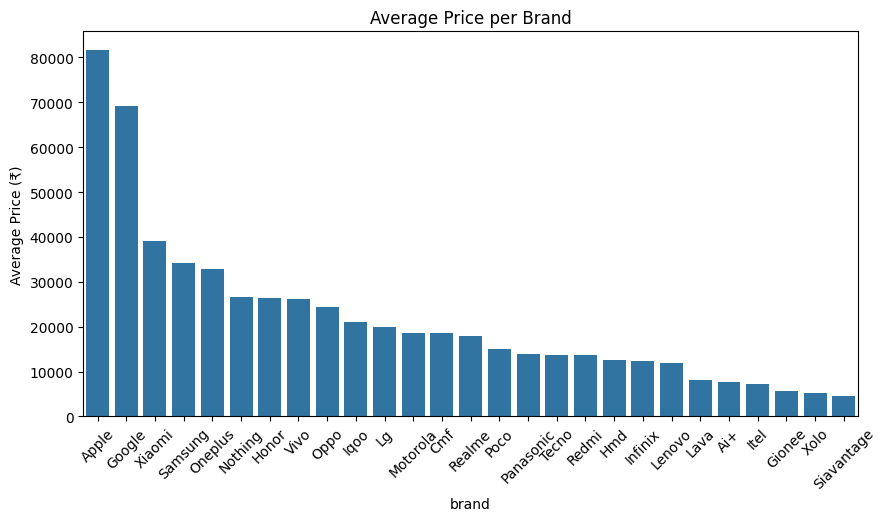

In [39]:

# 5) What is the average price of each brand?

avg_price = (
    df_grouped.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Price of Each Brand:\n", avg_price)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title("Average Price per Brand")
plt.xticks(rotation=45)
plt.ylabel("Average Price (₹)")
plt.show()

Models per Price Range:
 price_bin
10k-20k     111
0-10k        64
20k-30k      46
30k-40k      19
40k-60k      18
60k-100k     11
100k+         7
Name: model, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11252\1007745333.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped.groupby("price_bin")["model"]


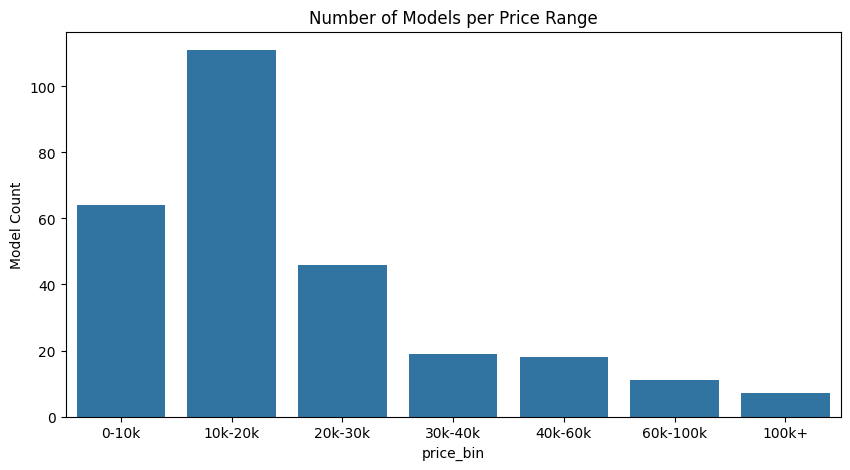

In [40]:
# 6) Most models are made in which price range?

bins = [0, 10000, 20000, 30000, 40000, 60000, 100000, df_grouped["price"].max()]
labels = ["0-10k", "10k-20k", "20k-30k", "30k-40k", "40k-60k", "60k-100k", "100k+"]

df_grouped["price_bin"] = pd.cut(df_grouped["price"], bins=bins, 
                                 labels=labels, include_lowest=True)

price_bin_models = (
    df_grouped.groupby("price_bin")["model"]
    .nunique()
    .sort_values(ascending=False)
)

print("Models per Price Range:\n", price_bin_models)

plt.figure(figsize=(10,5))
sns.barplot(x=price_bin_models.index, y=price_bin_models.values)
plt.title("Number of Models per Price Range")
plt.ylabel("Model Count")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11252\3060113482.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped.groupby("price_bin")["user"]


Users per Price Range:
 price_bin
10k-20k     112147410
0-10k        35494000
40k-60k      22234650
20k-30k      22103360
60k-100k     16754000
30k-40k       3787500
100k+          274110
Name: user, dtype: int64


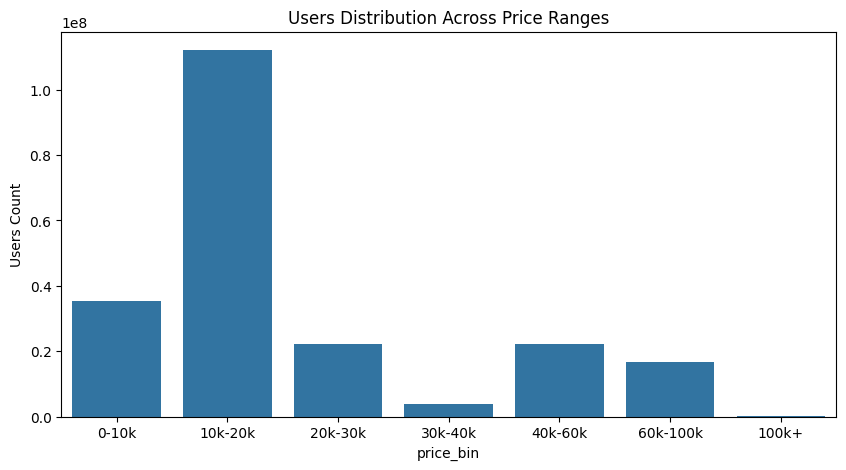

In [41]:
# 7) Most users lie in which price range?

price_bin_users = (
    df_grouped.groupby("price_bin")["user"]
    .sum()
    .sort_values(ascending=False)
)

print("Users per Price Range:\n", price_bin_users)

plt.figure(figsize=(10,5))
sns.barplot(x=price_bin_users.index, y=price_bin_users.values)
plt.title("Users Distribution Across Price Ranges")
plt.ylabel("Users Count")
plt.show()

In [ ]:
df_grouped.to_e